In [1]:
import os

for dirname, _, filenames in os.walk('/Users/shreeamsha/Downloads/Data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [2]:
import pandas as pd
import numpy as np
from tensorflow import keras
import warnings
warnings.filterwarnings(action="ignore")
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import TensorBoard,EarlyStopping

import sklearn.metrics as metrics
from keras.callbacks import LearningRateScheduler
from tensorflow.keras.utils import image_dataset_from_directory
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x, verbose=0)


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile
import os

zip_path = "drive/MyDrive/Data.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("extracted_folder")

os.listdir("extracted_folder")



['Data', '__MACOSX']

In [5]:
import os
import pandas as pd

base = '/content/extracted_folder/Data'

MildDemented_dir = os.path.join(base, 'MildDemented')
ModerateDemented_dir = os.path.join(base, 'ModerateDemented')
NonDemented_dir = os.path.join(base, 'NonDemented')
VeryMildDemented_dir = os.path.join(base, 'VeryMildDemented')

filepaths = []
labels = []

dict_list = [
    MildDemented_dir,
    ModerateDemented_dir,
    NonDemented_dir,
    VeryMildDemented_dir
]

class_labels = [
    'Mild Demented',
    'Moderate Demented',
    'Non Demented',
    'Very Mild Demented'
]

# 🔍 Safety check
for path in dict_list:
    print(path, "->", os.path.exists(path))

# 📂 Build dataframe
for i, j in enumerate(dict_list):
    flist = [f for f in os.listdir(j) if not f.startswith('.')]
    for f in flist:
        fpath = os.path.join(j, f)
        filepaths.append(fpath)
        labels.append(class_labels[i])

Alzheimer_df = pd.DataFrame({
    "filepaths": filepaths,
    "labels": labels
})

print(Alzheimer_df.head())
print(Alzheimer_df["labels"].value_counts())


/content/extracted_folder/Data/MildDemented -> True
/content/extracted_folder/Data/ModerateDemented -> True
/content/extracted_folder/Data/NonDemented -> True
/content/extracted_folder/Data/VeryMildDemented -> True
                                           filepaths         labels
0  /content/extracted_folder/Data/MildDemented/MR...  Mild Demented
1  /content/extracted_folder/Data/MildDemented/MR...  Mild Demented
2  /content/extracted_folder/Data/MildDemented/MR...  Mild Demented
3  /content/extracted_folder/Data/MildDemented/MR...  Mild Demented
4  /content/extracted_folder/Data/MildDemented/MR...  Mild Demented
labels
Mild Demented         10000
Moderate Demented     10000
Non Demented          10000
Very Mild Demented    10000
Name: count, dtype: int64


In [6]:
Alzheimer_df.shape

(40000, 2)

In [7]:
train_images, test_images = train_test_split(Alzheimer_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(Alzheimer_df, test_size=0.2, random_state=42)

In [8]:
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_images.shape)

(32000, 2)
(12000, 2)
(8000, 2)
(28000, 2)


In [9]:
image_gen = ImageDataGenerator(preprocessing_function= tf.keras.applications.mobilenet_v2.preprocess_input)
train = image_gen.flow_from_dataframe(dataframe= train_set,x_col="filepaths",y_col="labels",
                                      target_size=(244,244),
                                      color_mode='rgb',
                                      class_mode="categorical", #used for Sequential Model
                                      batch_size=32,
                                      shuffle=False            #do not shuffle data
                                     )
test = image_gen.flow_from_dataframe(dataframe= test_images,x_col="filepaths", y_col="labels",
                                     target_size=(244,244),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=32,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_set,x_col="filepaths", y_col="labels",
                                    target_size=(244,244),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=32,
                                    shuffle=False
                                   )

Found 32000 validated image filenames belonging to 4 classes.
Found 12000 validated image filenames belonging to 4 classes.
Found 8000 validated image filenames belonging to 4 classes.


In [10]:
classes=list(train.class_indices.keys())
print (classes)

['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very Mild Demented']


In [11]:
def show_knee_images(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen) # get a sample batch from the generator
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2 #scale images between 0 and 1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color="green",fontsize=16)
        plt.axis('off')
    plt.show()

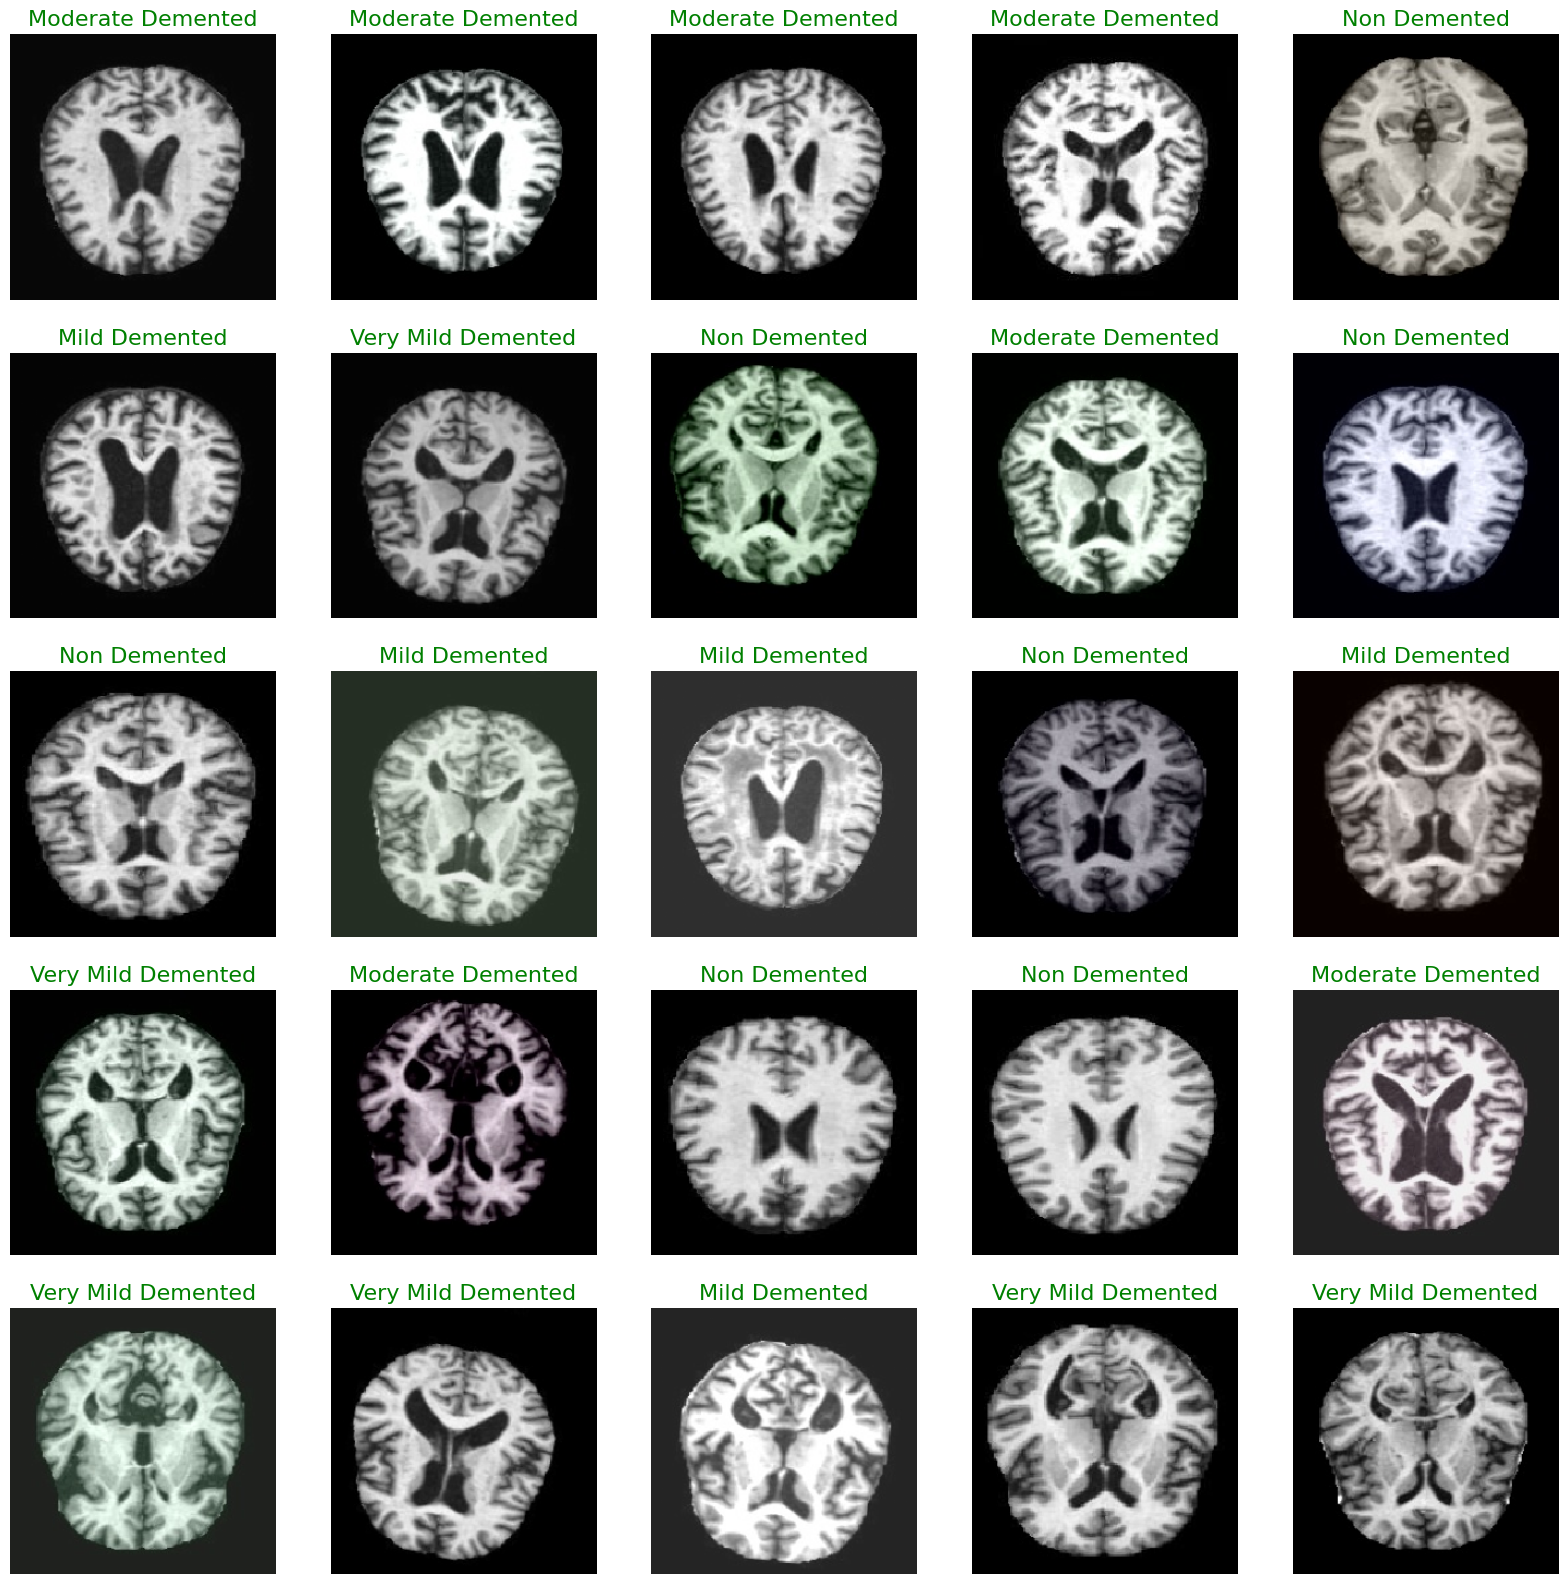

In [12]:
show_knee_images(train)

In [13]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=(224, 224, 3)),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3, 3)),

    keras.layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(4, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.optimizers.SGD(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 73, 73, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 73, 73, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 73, 73, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 73, 73, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 6, 6, 512)      │         2,04

 Total params: 15,611,524 (59.55 MB)

 Trainable params: 15,605,124 (59.53 MB)

 Non-trainable params: 6,400 (25.00 KB)

In [14]:
history = model.fit(train, epochs=22, validation_data=val, validation_freq=1)

Epoch 1/22
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 213s 185ms/step - accuracy: 0.4494 - loss: 1.2986 - val_accuracy: 0.6226 - val_loss: 0.8702
Epoch 2/22
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 180s 180ms/step - accuracy: 0.5976 - loss: 0.8698 - val_accuracy: 0.6678 - val_loss: 0.7207
Epoch 3/22
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 180s 180ms/step - accuracy: 0.6597 - loss: 0.7389 - val_accuracy: 0.6986 - val_loss: 0.6551
Epoch 4/22
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 204s 182ms/step - accuracy: 0.7084 - loss: 0.6408 - val_accuracy: 0.7437 - val_loss: 0.5786
Epoch 5/22
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 181s 181ms/step - accuracy: 0.7561 - loss: 0.5512 - val_accuracy: 0.7709 - val_loss: 0.5150
Epoch 6/22
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 181s 181ms/step - accuracy: 0.7992 - loss: 0.4593 - val_accuracy: 0.8170 - val_loss: 0.4370
Epoch 7/22
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 180s 180ms/step - accuracy: 0.8366 - loss: 0.3802 - val_accuracy: 0.8503 - val_loss: 0.3599
Epoch 8/22
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 181s 181ms/step - ac

In [15]:
model.evaluate(test, verbose=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.9509 - loss: 0.1950


[0.19501028954982758, 0.9509166479110718]

In [16]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/Osteoporosis_Model_binary.h5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
pred = model.predict(test)
pred = np.argmax(pred, axis=1) #pick class with highest  probability

labels = (train.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

375/375 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step


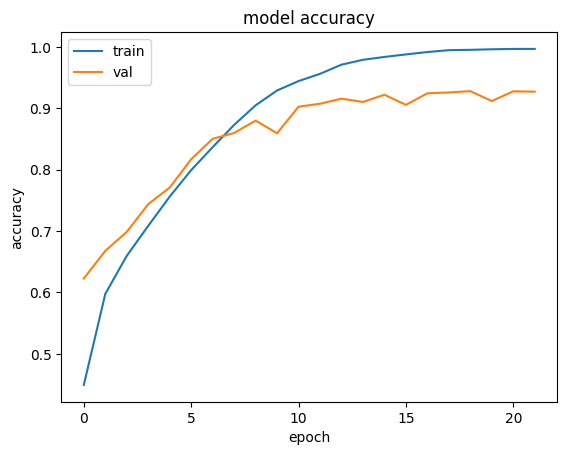

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

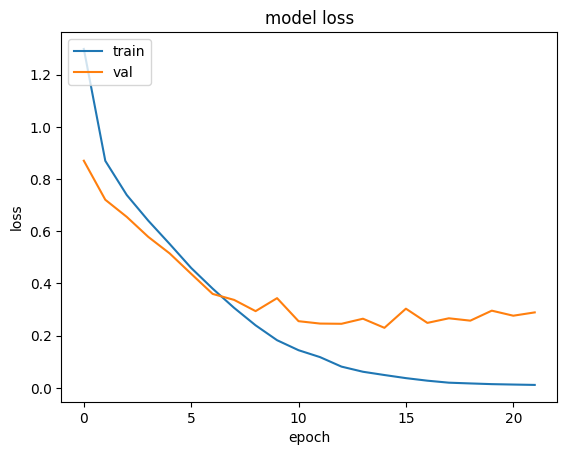

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_test = test_images.labels # set y_test to the expected output
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

                    precision    recall  f1-score   support

     Mild Demented       0.97      0.94      0.95      3066
 Moderate Demented       1.00      1.00      1.00      2931
      Non Demented       0.93      0.94      0.93      2995
Very Mild Demented       0.91      0.93      0.92      3008

          accuracy                           0.95     12000
         macro avg       0.95      0.95      0.95     12000
      weighted avg       0.95      0.95      0.95     12000

Accuracy of the Model: 95.1%


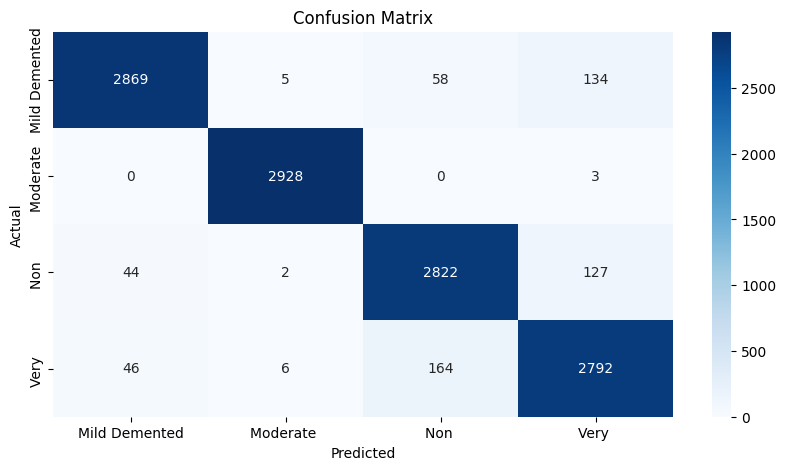

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define the class labels
class_labels = ['Mild Demented', 'Moderate ', 'Non ', 'Very ']

# Calculate the confusion matrix
cm = confusion_matrix(y_test, pred2)

# Create a figure and plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

# Set tick labels and axis labels
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Set the title
plt.title("Confusion Matrix")

# Show the plot
plt.show()

In [22]:
import zipfile
import os

zip_path = "drive/MyDrive/Data.zip"
extract_path = "drive/MyDrive/Data_extracted"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # Extract only first 20 images
    members = [m for m in zip_ref.namelist() if m.endswith(".jpg") or m.endswith(".png")]
    for m in members[:20]:
        zip_ref.extract(m, extract_path)

print("Extracted 20 images for testing!")

Extracted 20 images for testing!


In [24]:
import os

test_folder = '/content/extracted_folder/Data'

img_files = []
for root, dirs, files in os.walk(test_folder):
    for f in files:
        if f.endswith(".jpg") or f.endswith(".png"):
            img_files.append(os.path.join(root, f))

print("Total images found:", len(img_files))

Total images found: 40000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


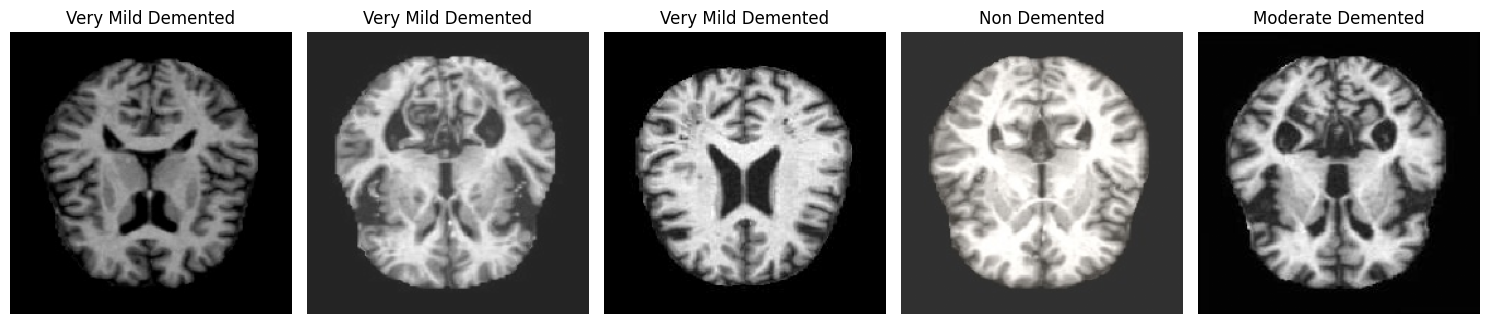

In [26]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np
import tensorflow as tf
from PIL import Image, UnidentifiedImageError

labels = {v: k for k, v in train.class_indices.items()}

# Pick 5 random images first
random_images = random.sample(img_files, 20)  # pick 20 candidates to filter

# Keep only valid images
valid_images = []
for f in random_images:
    try:
        Image.open(f).verify()
        valid_images.append(f)
    except (UnidentifiedImageError, IOError):
        continue
    if len(valid_images) == 5:  # stop once we have 5 valid images
        break

plt.figure(figsize=(15, 5))
for i, img_path in enumerate(valid_images):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = np.argmax(pred, axis=1)[0]
    pred_label = labels[pred_class]

    plt.subplot(1, 5, i+1)
    plt.imshow((img_array[0]+1)/2)
    plt.title(pred_label, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()